Data Loading 

In [7]:
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve

# Error Handling for Data Loading
try:
    current_dir = os.getcwd()
    # Path assumes notebook is in 'notebooks/' folder
    data_path = os.path.join(current_dir, '..', 'data', 'processed', 'processed_fraud_data.csv')
    df = pd.read_csv(data_path)
    print(f"Data loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'processed_fraud_data.csv' not found. Run preprocessing first.")

Data loaded successfully. Shape: (151112, 17)


Data Splitting and Resampling (SMOTE)

In [8]:
# Select features and target
X = df.drop(columns=['class', 'user_id', 'device_id', 'signup_time', 'purchase_time'])
y = df['class']

# Split BEFORE resampling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE to training data ONLY
print("Applying SMOTE to training data...")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Resampled training shape: {X_train_res.shape}")

Applying SMOTE to training data...
Original training shape: (120889, 12)
Resampled training shape: (219136, 12)


Baseline Model (Logistic Regression)

In [9]:
print("Training Logistic Regression Baseline...")
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_res, y_train_res)

# Evaluate Baseline
lr_probs = lr_baseline.predict_proba(X_test)[:, 1]
lr_auc_pr = average_precision_score(y_test, lr_probs)
print(f"Baseline Logistic Regression AUC-PR: {lr_auc_pr:.4f}")

Training Logistic Regression Baseline...
Baseline Logistic Regression AUC-PR: 0.0910


Hyperparameter Tuning (Random Forest)

In [10]:
print("Starting Hyperparameter Tuning for Random Forest...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=3)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)
best_rf = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")

Starting Hyperparameter Tuning for Random Forest...
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


Final Model Comparison and Export


--- Logistic Regression (Baseline) Results ---
AUC-PR: 0.0910


c:\Users\Home-User\WK5-fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Home-User\WK5-fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Home-User\WK5-fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     27393
           1       0.00      0.00      0.00      2830

    accuracy                           0.91     30223
   macro avg       0.45      0.50      0.48     30223
weighted avg       0.82      0.91      0.86     30223


--- Random Forest (Tuned) Results ---
AUC-PR: 0.6870
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     27393
           1       0.74      0.58      0.65      2830

    accuracy                           0.94     30223
   macro avg       0.85      0.78      0.81     30223
weighted avg       0.94      0.94      0.94     30223



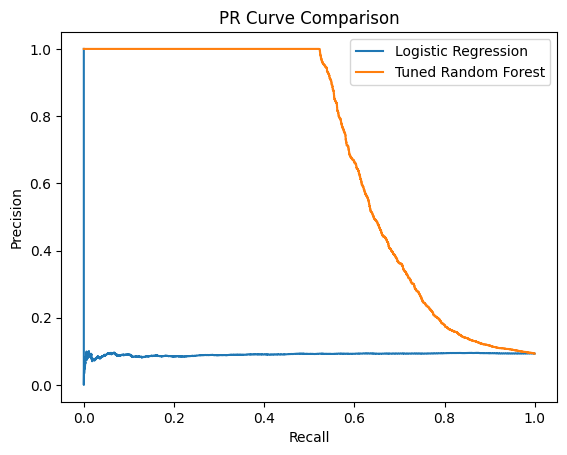

['../models/random_forest_fraud_model.pkl']

In [11]:
def report_metrics(model, name):
    probs = model.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, probs)
    print(f"\n--- {name} Results ---")
    print(f"AUC-PR: {auc_pr:.4f}")
    print(classification_report(y_test, model.predict(X_test)))
    return precision_recall_curve(y_test, probs)

# Run Comparison
p_lr, r_lr, _ = report_metrics(lr_baseline, "Logistic Regression (Baseline)")
p_rf, r_rf, _ = report_metrics(best_rf, "Random Forest (Tuned)")

# Plot Precision-Recall Curves
plt.plot(r_lr, p_lr, label='Logistic Regression')
plt.plot(r_rf, p_rf, label='Tuned Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve Comparison')
plt.legend()
plt.show()

# Save the winning model
joblib.dump(best_rf, '../models/random_forest_fraud_model.pkl')